# Comparación de configuraciones de clustering

Comparación conjunta de los modelos mediante las métricas internas comunes. Se estudian tanto las configuraciones mejor puntuadas como las peores y el comportamiento agregado por algoritmo y versión del dataset.

## Criterio de selección

El ranking combina silhouette y Calinski-Harabasz, donde un valor mayor es mejor, y Davies-Bouldin, donde un valor menor es mejor. Las posiciones se calculan únicamente dentro de cada dataset: todas las configuraciones simple y extended de H&M compiten entre sí, y todas las configuraciones simple y extended de Instacart compiten entre sí. La puntuación final varía entre 0 y 100 y asigna el mismo peso a las tres métricas.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## Carga de las métricas consolidadas

In [2]:
csv_path = Path("../../results/clustering/clustering_metrics.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "No se encontró results/clustering/clustering_metrics.csv. "
        "Ejecuta primero las celdas de exportación de los modelos."
    )

metricas = pd.read_csv(csv_path)
print(f"Configuraciones disponibles: {len(metricas)}")
display(metricas.head())

Configuraciones disponibles: 252


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN


## Cálculo de la puntuación conjunta

In [3]:
columnas_grupo = ["dataset"]
ranking = metricas.copy()

ranking["rank_silhouette"] = (
    ranking.groupby(columnas_grupo)["silhouette"]
    .rank(method="average", ascending=False)
)
ranking["rank_calinski_harabasz"] = (
    ranking.groupby(columnas_grupo)["calinski_harabasz"]
    .rank(method="average", ascending=False)
)
ranking["rank_davies_bouldin"] = (
    ranking.groupby(columnas_grupo)["davies_bouldin"]
    .rank(method="average", ascending=True)
)

ranking["rank_medio"] = ranking[[
    "rank_silhouette",
    "rank_calinski_harabasz",
    "rank_davies_bouldin",
]].mean(axis=1)

tamano_grupo = ranking.groupby(columnas_grupo)["k"].transform("size")
ranking["puntuacion"] = (
    100 * (1 - (ranking["rank_medio"] - 1) / (tamano_grupo - 1))
).round(2)

## Top 10 de H&M


In [4]:
columnas_top = [
    "model",
    "dataset",
    "dataset_version",
    "k",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "tiempo_segundos",
    "puntuacion",
]

def obtener_extremos(ranking, dataset, n=10):
    ordenado = (
        ranking.loc[ranking["dataset"] == dataset]
        .sort_values(
            ["puntuacion", "silhouette", "calinski_harabasz", "davies_bouldin"],
            ascending=[False, False, False, True],
        )
        [columnas_top]
    )
    top = ordenado.head(n).reset_index(drop=True)
    bottom = ordenado.tail(n).sort_values("puntuacion").reset_index(drop=True)
    top.index = top.index + 1
    top.index.name = "posición"
    bottom.index = bottom.index + 1
    bottom.index.name = "posición desde el final"
    return top, bottom

top_10_hym, bottom_10_hym = obtener_extremos(ranking, "hym")
display(top_10_hym)
display(bottom_10_hym)

,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos,puntuacion
posición,,,,,,,,,
1,minibatch,hym,simple,2,0.499415,1.964706e+06,0.754819,1.870814,99.20
2,kmeans,hym,simple,2,0.498940,1.965255e+06,0.756811,3.701281,99.20
3,bisecting,hym,simple,2,0.498926,1.965253e+06,0.756912,2.627902,98.40
4,fuzzy,hym,simple,2,0.497600,1.962447e+06,0.761190,5.872886,97.33
5,gmm,hym,simple,2,0.479295,1.822393e+06,0.796233,4.535898,96.27
6,birch,hym,simple,2,0.482675,1.681837e+06,0.713841,11.338001,95.73
7,clara,hym,simple,2,0.468605,1.761797e+06,0.800249,0.683154,94.67
8,minibatch,hym,simple,3,0.414013,1.786461e+06,0.898736,0.916977,94.13
9,kmeans,hym,simple,3,0.413689,1.786798e+06,0.900861,3.743179,93.87


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos,puntuacion
posición desde el final,,,,,,,,,
1,fuzzy,hym,extended,10,0.079766,247158.166672,3.556713,207.804702,0.27
2,fuzzy,hym,extended,9,0.077800,263044.169005,3.543943,264.039036,0.80
3,fuzzy,hym,extended,8,0.093376,314145.350118,3.003989,120.752752,4.00
4,gmm,hym,extended,10,0.112476,270949.224814,2.096721,30.636218,5.33
5,clara,hym,extended,9,0.112701,250192.360214,2.010889,1.615172,5.87
6,gmm,hym,extended,8,0.112430,309099.365017,2.211720,23.450397,5.87
7,gmm,hym,extended,9,0.117190,291188.328029,2.147412,25.743142,6.13
8,fuzzy,hym,extended,7,0.097022,344253.242764,2.895362,53.830272,6.40
9,clara,hym,extended,7,0.120845,322722.792360,2.059177,1.493331,9.60


## Top 10 de Instacart


In [5]:
top_10_instacart, bottom_10_instacart = obtener_extremos(ranking, "instacart")
display(top_10_instacart)
display(bottom_10_instacart)

pd.concat([top_10_hym.assign(tramo="top"), top_10_instacart.assign(tramo="top")]).to_csv(
    csv_path.parent / "clustering_top10.csv", index=False
)
pd.concat([bottom_10_hym.assign(tramo="bottom"), bottom_10_instacart.assign(tramo="bottom")]).to_csv(
    csv_path.parent / "clustering_bottom10.csv", index=False
)

,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos,puntuacion
posición,,,,,,,,,
1,kmeans,instacart,simple,5,0.304233,101036.143303,1.039441,0.975162,93.87
2,kmeans,instacart,simple,4,0.316122,104145.226760,1.084668,0.691496,93.33
3,minibatch,instacart,simple,4,0.315253,103513.427021,1.090711,0.322533,92.27
4,kmeans,instacart,simple,6,0.305732,97505.367067,1.041639,1.113987,90.93
5,fuzzy,instacart,simple,4,0.309961,102987.513224,1.106799,4.108251,90.13
6,clara,instacart,simple,4,0.309014,100392.355005,1.097605,0.101510,90.13
7,minibatch,instacart,simple,5,0.304326,98993.819699,1.067747,0.489551,89.60
8,fuzzy,instacart,simple,5,0.297118,99789.918261,1.079599,10.130256,88.80
9,bisecting,instacart,simple,2,0.325604,105945.774703,1.277899,0.570038,88.13


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos,puntuacion
posición desde el final,,,,,,,,,
1,fuzzy,instacart,extended,10,0.086400,36140.491573,2.808383,36.566694,1.60
2,fuzzy,instacart,extended,9,0.094117,39253.663852,2.936210,33.418157,2.40
3,gmm,instacart,simple,10,0.124142,38229.004898,6.380328,2.133450,2.67
4,gmm,instacart,simple,7,0.112344,43418.073961,3.949242,2.175252,3.73
5,fuzzy,instacart,extended,8,0.101752,43542.047259,2.540563,30.028276,4.80
6,clara,instacart,extended,10,0.126789,40811.146759,1.869886,0.191023,6.67
7,gmm,instacart,extended,10,0.112863,36256.837201,1.706418,4.356120,7.20
8,gmm,instacart,simple,8,0.129245,46435.299344,3.798379,1.771070,7.73
9,clara,instacart,extended,7,0.128732,45918.084218,1.833524,0.164965,9.33


## Comparación gráfica


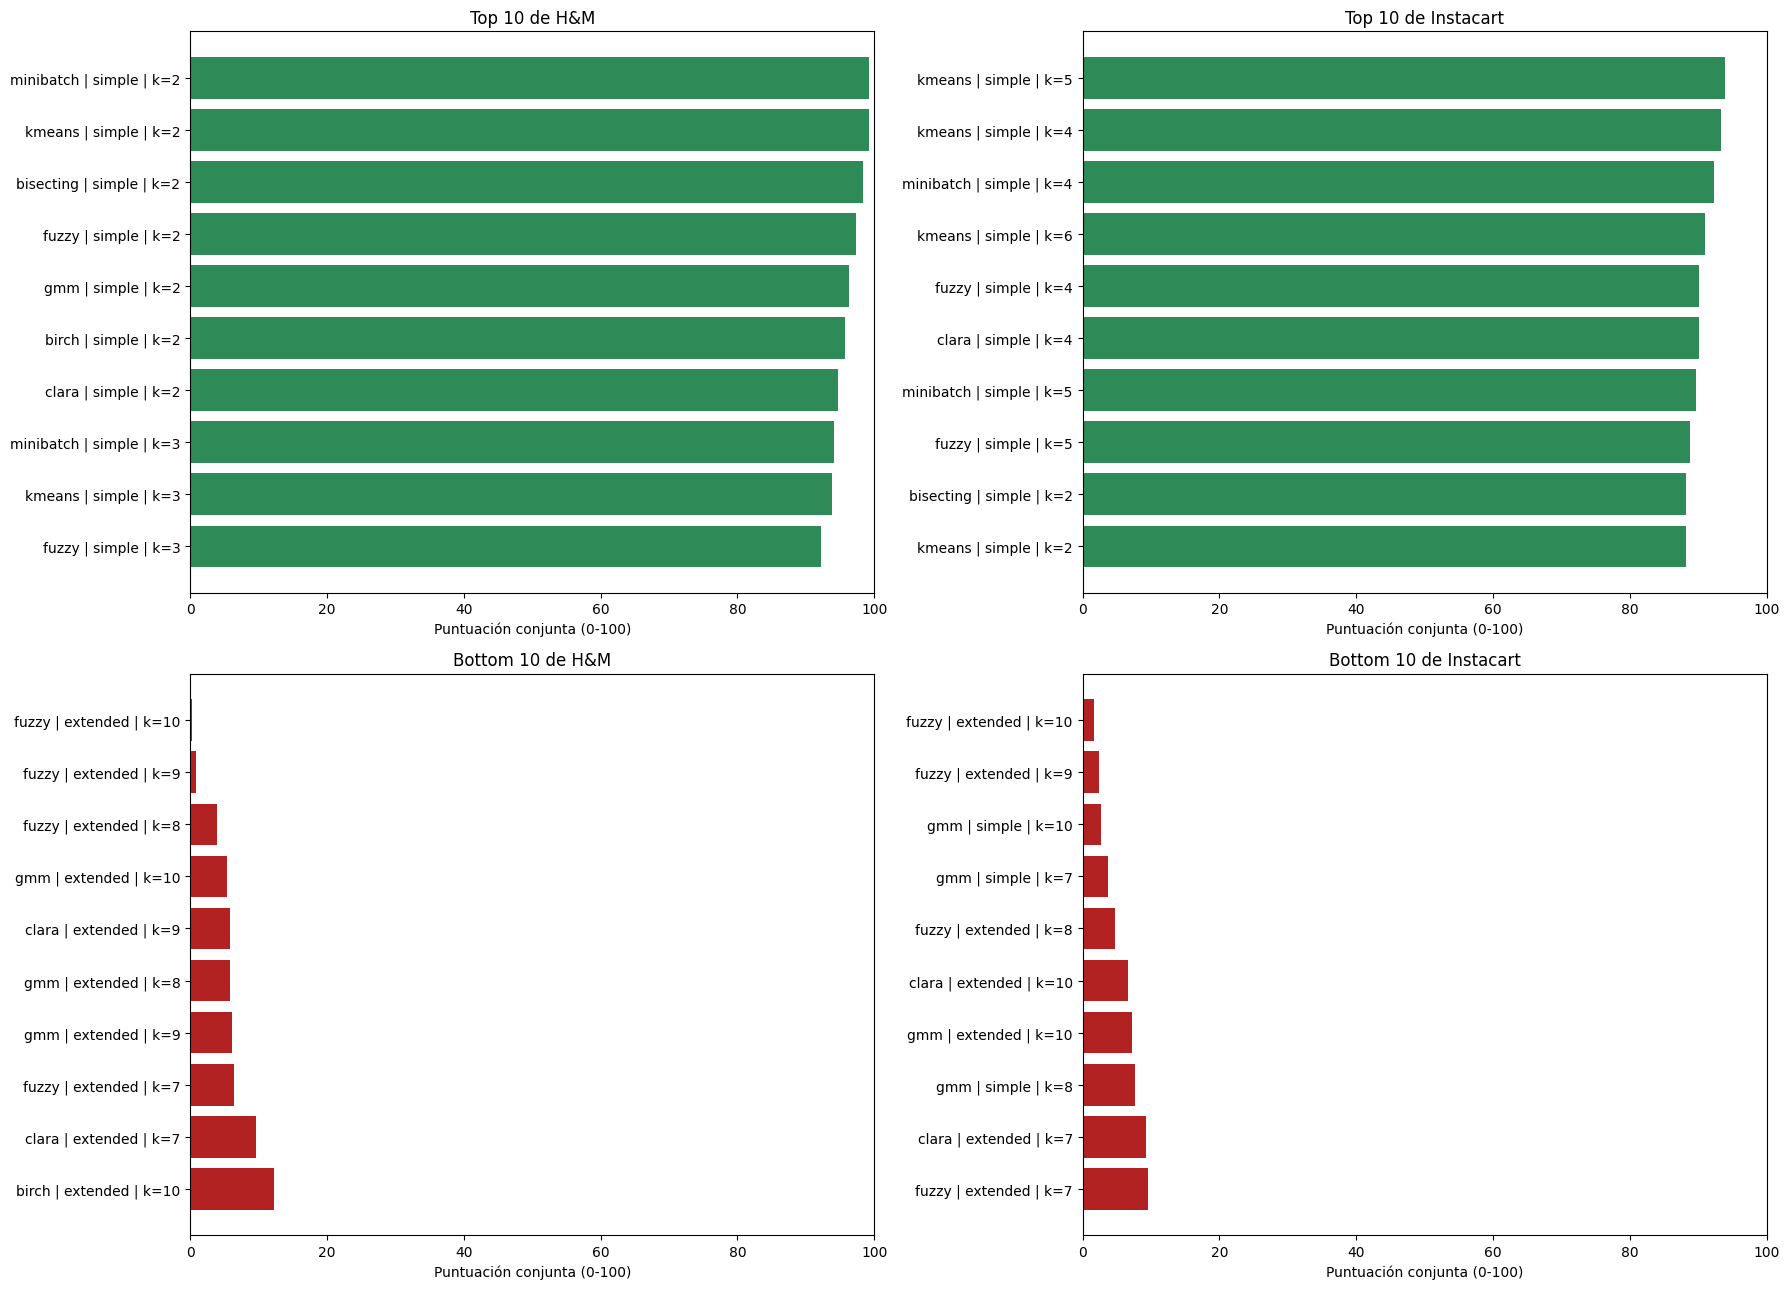

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

for ax, top, titulo, color in [
    (axes[0, 0], top_10_hym, "Top 10 de H&M", "#2E8B57"),
    (axes[0, 1], top_10_instacart, "Top 10 de Instacart", "#2E8B57"),
    (axes[1, 0], bottom_10_hym, "Bottom 10 de H&M", "#B22222"),
    (axes[1, 1], bottom_10_instacart, "Bottom 10 de Instacart", "#B22222"),
]:
    etiquetas = (
        top["model"]
        + " | " + top["dataset_version"]
        + " | k=" + top["k"].astype(str)
    )
    ax.barh(etiquetas[::-1], top["puntuacion"][::-1], color=color)
    ax.set_title(titulo)
    ax.set_xlabel("Puntuación conjunta (0-100)")
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

## Mejor configuración por dataset

In [7]:
mejores_por_dataset = (
    ranking.sort_values(
        ["puntuacion", "silhouette", "calinski_harabasz", "davies_bouldin"],
        ascending=[False, False, False, True],
    )
    .groupby(columnas_grupo, as_index=False)
    .first()[columnas_top]
    .sort_values(["dataset", "dataset_version"])
)
display(mejores_por_dataset)

peores_por_dataset = (
    ranking.sort_values(
        ["puntuacion", "silhouette", "calinski_harabasz", "davies_bouldin"],
        ascending=[True, True, True, False],
    )
    .groupby(columnas_grupo, as_index=False)
    .first()[columnas_top]
)
display(peores_por_dataset)

resumen_algoritmos = (
    ranking.groupby(["dataset", "model"], as_index=False)
    .agg(
        puntuacion_media=("puntuacion", "mean"),
        puntuacion_mediana=("puntuacion", "median"),
        mejor_puntuacion=("puntuacion", "max"),
        peor_puntuacion=("puntuacion", "min"),
        tiempo_medio=("tiempo_segundos", "mean"),
    )
    .sort_values(["dataset", "puntuacion_media"], ascending=[True, False])
)
resumen_versiones = (
    ranking.groupby(["dataset", "dataset_version"], as_index=False)
    .agg(
        puntuacion_media=("puntuacion", "mean"),
        mejor_puntuacion=("puntuacion", "max"),
        peor_puntuacion=("puntuacion", "min"),
    )
)
display(resumen_algoritmos.round(3))
display(resumen_versiones.round(3))
resumen_algoritmos.to_csv(csv_path.parent / "clustering_algorithm_comparison.csv", index=False)
resumen_versiones.to_csv(csv_path.parent / "clustering_version_comparison.csv", index=False)

,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos,puntuacion
0,minibatch,hym,simple,2,0.499415,1.964706e+06,0.754819,1.870814,99.20
1,kmeans,instacart,simple,5,0.304233,1.010361e+05,1.039441,0.975162,93.87


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,tiempo_segundos,puntuacion
0,fuzzy,hym,extended,10,0.079766,247158.166672,3.556713,207.804702,0.27
1,fuzzy,instacart,extended,10,0.086400,36140.491573,2.808383,36.566694,1.60


,dataset,model,puntuacion_media,puntuacion_mediana,mejor_puntuacion,peor_puntuacion,tiempo_medio
5,hym,kmeans,60.016,67.335,99.20,26.67,12.935
6,hym,minibatch,57.941,60.400,99.20,25.33,4.028
1,hym,bisecting,51.289,56.400,98.40,13.87,4.070
0,hym,birch,50.489,62.000,95.73,12.27,33.339
3,hym,fuzzy,49.378,61.470,97.33,0.27,97.695
2,hym,clara,47.378,54.135,94.67,5.87,1.159
4,hym,gmm,33.512,29.730,96.27,5.33,13.951
12,instacart,kmeans,65.748,78.200,93.87,25.60,1.605
13,instacart,minibatch,61.216,77.200,92.27,20.53,0.392
10,instacart,fuzzy,52.296,74.670,90.13,1.60,18.251


,dataset,dataset_version,puntuacion_media,mejor_puntuacion,peor_puntuacion
0,hym,extended,28.352,68.00,0.27
1,hym,simple,71.649,99.20,13.07
2,instacart,extended,33.160,75.87,1.60
3,instacart,simple,66.840,93.87,2.67


## Visualización de los mejores clusters

Los clusters se representan mediante una proyección PCA de dos componentes. El modelo se ajusta con todas las observaciones y el gráfico utiliza una muestra reproducible de hasta 10.000 clientes para mantener la visualización legible.

In [8]:
import sys

from sklearn.decomposition import PCA

MODELING_DIR = Path.cwd().parent / "03_modeling"
if str(MODELING_DIR) not in sys.path:
    sys.path.append(str(MODELING_DIR))

from modeling_functions import fit_clustering_model

In [9]:
rutas_datos = {
    ("hym", "simple"): (
        "../../scaled_data/hym_scaled.csv",
        "../../simple_datasets/hym_model_simple.csv",
        "customer_id",
    ),
    ("hym", "extended"): (
        "../../scaled_data/hym_scaled.csv",
        "../../extended_datasets/hym_model_extended.csv",
        "customer_id",
    ),
    ("instacart", "simple"): (
        "../../scaled_data/instacart_scaled.csv",
        "../../simple_datasets/instacart_model_simple.csv",
        "user_id",
    ),
    ("instacart", "extended"): (
        "../../scaled_data/instacart_scaled.csv",
        "../../extended_datasets/instacart_model_extended.csv",
        "user_id",
    ),
}

In [10]:
def preparar_visualizacion(mejor_fila, sample_size=10_000):
    dataset = mejor_fila["dataset"]
    version = mejor_fila["dataset_version"]
    model_name = mejor_fila["model"]
    k = int(mejor_fila["k"])

    scaled_path, original_path, id_col = rutas_datos[(dataset, version)]
    columnas_originales = pd.read_csv(original_path, nrows=0).columns
    df_scaled = pd.read_csv(scaled_path)
    columnas_modelo = [
        columna for columna in columnas_originales
        if columna in df_scaled.columns
    ]
    X = df_scaled[columnas_modelo].drop(
        columns=[id_col], errors="ignore"
    )

    _, labels = fit_clustering_model(
        model_name=model_name,
        k=k,
        X=X,
    )

    muestra = X.sample(
        n=min(sample_size, len(X)),
        random_state=42,
    )
    labels_muestra = labels[muestra.index]
    pca = PCA(n_components=2, random_state=42)
    coordenadas = pca.fit_transform(muestra)

    visualizacion = pd.DataFrame({
        "Componente 1": coordenadas[:, 0],
        "Componente 2": coordenadas[:, 1],
        "cluster": labels_muestra,
    })
    varianza = pca.explained_variance_ratio_.sum() * 100
    titulo = (
        f"{dataset.upper()} | {model_name} | {version} | k={k}"
    )
    return visualizacion, titulo, varianza

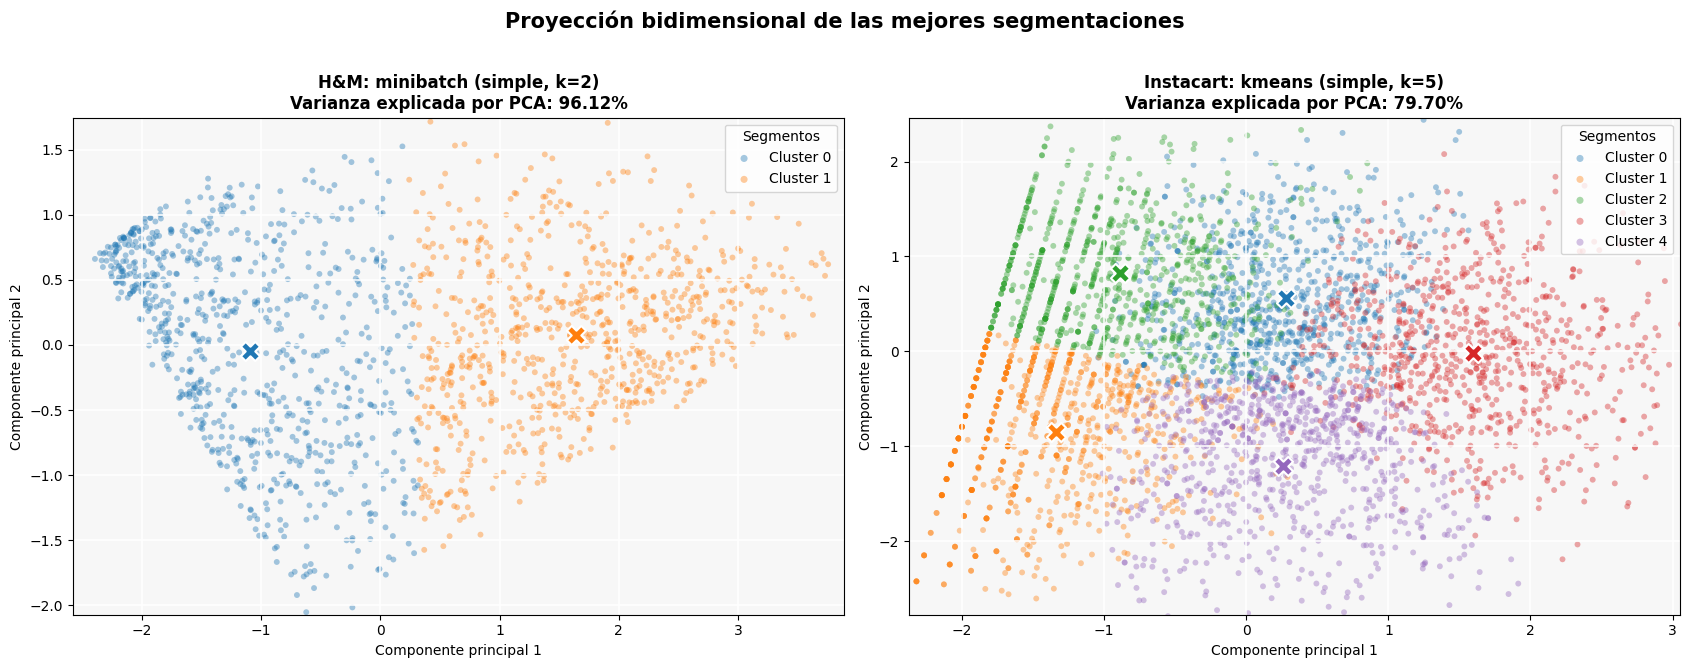

In [11]:
mejores_filas = {
    fila["dataset"]: fila
    for _, fila in mejores_por_dataset.iterrows()
}

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
colores = plt.get_cmap("tab10")

for ax, dataset in zip(axes, ["hym", "instacart"]):
    datos_plot, titulo, varianza = preparar_visualizacion(
        mejores_filas[dataset]
    )

    for cluster in sorted(datos_plot["cluster"].unique()):
        datos_cluster = datos_plot.loc[
            datos_plot["cluster"] == cluster
        ]
        muestra_cluster = datos_cluster.sample(
            n=min(800, len(datos_cluster)),
            random_state=42,
        )

        ax.scatter(
            muestra_cluster["Componente 1"],
            muestra_cluster["Componente 2"],
            color=colores(int(cluster) % 10),
            label=f"Cluster {cluster}",
            s=18,
            alpha=0.40,
            edgecolors="none",
        )

        centroide = datos_cluster[[
            "Componente 1", "Componente 2"
        ]].mean()
        ax.scatter(
            centroide["Componente 1"],
            centroide["Componente 2"],
            color=colores(int(cluster) % 10),
            marker="X",
            s=190,
            edgecolor="white",
            linewidth=1.5,
            zorder=5,
        )

    limite_x = datos_plot["Componente 1"].quantile([0.005, 0.995])
    limite_y = datos_plot["Componente 2"].quantile([0.005, 0.995])
    margen_x = (limite_x.iloc[1] - limite_x.iloc[0]) * 0.05
    margen_y = (limite_y.iloc[1] - limite_y.iloc[0]) * 0.05
    ax.set_xlim(limite_x.iloc[0] - margen_x, limite_x.iloc[1] + margen_x)
    ax.set_ylim(limite_y.iloc[0] - margen_y, limite_y.iloc[1] + margen_y)

    nombre_dataset = "H&M" if dataset == "hym" else "Instacart"
    modelo = mejores_filas[dataset]["model"]
    version = mejores_filas[dataset]["dataset_version"]
    k = int(mejores_filas[dataset]["k"])
    ax.set_title(
        f"{nombre_dataset}: {modelo} ({version}, k={k})\n"
        f"Varianza explicada por PCA: {varianza:.2f}%",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.set_facecolor("#f7f7f7")
    ax.grid(color="white", linewidth=1.1)
    ax.legend(frameon=True, title="Segmentos", markerscale=1.2)

fig.suptitle(
    "Proyección bidimensional de las mejores segmentaciones",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()
